# Описание задачи "Разработка нефтегазовых месторождений"

Набор данных содержит 442 о различных нефтегазовых месторождениях.
Тренировочный набор - 309 строк.
Тестовый набор - 133 строк.

Каждое месторождение обладает 19 параметрами:
1. Field name - название месторождения
2. Reservoir unit - юнит месторождения
3. Country - страна расположения
4. Region - регион расположения
5. Basin name - название бассейна пород
6. Tectonic regime - тектонический режим
7. Latitude - широта
8. Longitude - долгота
9. Operator company - название компании
10. Onshore or oﬀshore - на суше или нет
11. Hydrocarbon type (main) - тип углеводорода
12. Reservoir status (current) - статус месторождения
13. Structural setting - структурные свойства
14. Depth (top reservoir ft TVD) - глубина
15. Reservoir period - литологический период
16. Lithology (main) - литология
17. Thickness (gross average ft) - общая толщина
18. Thickness (net pay average ft) - эффективная толщина
19. Porosity (matrix average.. - пористость
20. Permeability (air average mD) – проницаемость

**Что нужно сделать**:

Принять участие в соревновании на Kaggle:
Оно доступно по [ссылке](https://www.kaggle.com/competitions/classification-of-oil-and-gas/submissions#).

Разработать и оформить решение в ноутбуке:
* Исследование и анализ датасета.
* Предобработка данных.
* Feature Engineering (если необходимо).
* Подбор признаков, их анализ и оценка важности.
* Обучение нескольких моделей, их сравнение.
* Подбор гиперпараметров.
* Выбор лучшей модели и объяснение выбора.
* Предсказание на тестовых данных.


|**Критерии оценивания**||
|:---|:---|
|Анализ данных и их предобработка	|0-3 балла|
|Feature Engineering и отбор признаков	|0-2 балла|
|Выбор и обучение нескольких моделей	|0-3 балла|
|Подбор гиперпараметров и объяснение выбора лучшей модели	|0-2 балла|
|Результат на Kaggle	|0-1 балл|
|Качество оформления ноутбука (чистый код, комментарии, выводы)	|0-1 балл|
|**Итого**	|**12 баллов**|


# Считывание данных

In [1]:
import opendatasets as od

# Загрузим датасет на прямую с kaggle
# Для автомтическй загрузки надо положить файл kaggle.json в папку с ноутбуком
# kaggle.json скачивается в настройках Kaggle в разделе Legacy API Credentials
dataset_url = 'https://www.kaggle.com/competitions/classification-of-oil-and-gas/data'

od.download(dataset_url)

Skipping, found downloaded files in "./classification-of-oil-and-gas" (use force=True to force download)


In [2]:
# иморитирование всех необходимых библиотек
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Считываем тренировочные данные
train = pd.read_csv("./classification-of-oil-and-gas/train_oil.csv")
test = pd.read_csv("./classification-of-oil-and-gas/oil_test.csv")

print(f"Train dataset shape: {train.shape}")
print(f"Test dataset shape: {test.shape}")

Train dataset shape: (309, 20)
Test dataset shape: (133, 19)


In [4]:
# Посмотрим как выглядят данные
train.head(5)

,Field name,Reservoir unit,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
0,ZHIRNOV,MELEKESKIAN,RUSSIA,FORMER SOVIET UNION,VOLGA-URAL,COMPRESSION/EVAPORITE,51.0000,44.8042,NIZHNEVOLZHSKNET,ONSHORE,OIL,DECLINING PRODUCTION,FORELAND,1870,CARBONIFEROUS,SANDSTONE,262.0,33.0,24.0,30.0
1,LAGOA PARDA,LAGOA PARDA (URUCUTUCA),BRAZIL,LATIN AMERICA,ESPIRITO SANTO,EXTENSION,-19.6017,-39.8332,PETROBRAS,ONSHORE,OIL,NEARLY DEPLETED,PASSIVE MARGIN,4843,PALEOGENE,SANDSTONE,2133.0,72.0,23.0,350.0
2,ABQAIQ,ARAB D,SAUDI ARABIA,MIDDLE EAST,THE GULF,COMPRESSION/EVAPORITE,26.0800,49.8100,SAUDI ARAMCO,ONSHORE,OIL,REJUVENATING,FORELAND,6050,JURASSIC,LIMESTONE,250.0,184.0,21.0,410.0
3,MURCHISON,BRENT,UK /NORWAY,EUROPE,NORTH SEA NORTHERN,EXTENSION,61.3833,1.7500,CNR,OFFSHORE,OIL,NEARLY DEPLETED,RIFT,8988,JURASSIC,SANDSTONE,425.0,300.0,22.0,750.0
4,WEST PEMBINA,NISKU (PEMBINA L POOL),CANADA,NORTH AMERICA,WESTERN CANADA,COMPRESSION,53.2287,-115.8008,NUMEROUS,ONSHORE,OIL,UNKNOWN,FORELAND,9306,DEVONIAN,DOLOMITE,233.0,167.0,11.8,1407.0


# Иследование и обработка данных (EDA)

## Общая информация

In [5]:
# процент дублей 
(len(train) - len( train.drop_duplicates() )) * 100 / len(train)

0.0

Дублирующих строк нет.

In [6]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Field name                      309 non-null    str    
 1   Reservoir unit                  309 non-null    str    
 2   Country                         282 non-null    str    
 3   Region                          271 non-null    str    
 4   Basin name                      271 non-null    str    
 5   Tectonic regime                 309 non-null    str    
 6   Latitude                        282 non-null    float64
 7   Longitude                       279 non-null    float64
 8   Operator company                309 non-null    str    
 9   Onshore/Offshore                309 non-null    str    
 10  Hydrocarbon type                309 non-null    str    
 11  Reservoir status                309 non-null    str    
 12  Structural setting              309 non-null   

In [7]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 133 entries, 0 to 132
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Field name                      133 non-null    str    
 1   Reservoir unit                  133 non-null    str    
 2   Country                         120 non-null    str    
 3   Region                          117 non-null    str    
 4   Basin name                      125 non-null    str    
 5   Tectonic regime                 133 non-null    str    
 6   Latitude                        120 non-null    float64
 7   Longitude                       117 non-null    float64
 8   Operator company                133 non-null    str    
 9   Hydrocarbon type                133 non-null    str    
 10  Reservoir status                133 non-null    str    
 11  Structural setting              133 non-null    str    
 12  Depth                           133 non-null   

## Обработка пропущенных значений

### Обзор

Есть пропущенные значения в тренировочных и тестовых данных. Визуализируем пропуски.

In [8]:
# Выведем список колонок с пропущенными значениями
train.isna().sum()[train.isna().sum() > 0]

Country       27
Region        38
Basin name    38
Latitude      27
Longitude     30
dtype: int64

In [9]:
train.isna().sum().sum()

np.int64(160)

Поле Field name (название месторождения) у нас везде заполнено и если оно будет встречаться и там, и там, то по нему мы попробуем востановить пропущенные значения.

In [10]:
def fill_na(train_df, check_col, test_df):
    """Принимает train, поле, по которому надо свернуть, чтобы получить "средние", test.
    Возвращает: пересечние, где нет значений и где есть в train, заполненные ими train, test.
    """
    
    # Разделим данные на две таблицы, где есть пропуски и где все поля заполнены
    
    # .any(axis='columns') - перебирает все строки и помечает всю строку True, если есть хотя бы один NaN в любой колонке
    missed = train_df[train_df.isna().any(axis='columns')] 
    
    filled = train_df.dropna()
    
    # Получим список заполненных полей    
    filled_names = filled[check_col].unique()
    
    # Отберём те строки, в таблице с пропусками, которые есть без пропусков
    common_names = missed[missed[check_col].isin(filled_names)]
    
    # Выведем результат из общей таблицы, чтобы визауально оценить возможность заполнения пропусков
    visual_check = train_df[train_df[check_col].isin(common_names[check_col])].sort_values(check_col)

    # создадим таблицу справочник с модой и медианой по названию месторождения
    mapping = filled.groupby(check_col).agg({
        'Country': lambda x: x.mode().iat[0], # так как мода вычисляется, то для указания индекса используем iat 
        'Region': lambda x: x.mode().iat[0],
        'Basin name': lambda x: x.mode().iat[0],
        'Latitude': 'median',
        'Longitude':'median',
    })
        
    # Заполнение, сбрасываем индекс на название, заполняем из справочника, восстанавливаем индекс
    train_df_filled = train_df.set_index(check_col).fillna(mapping).reset_index()
    test_df_filled = test_df.set_index(check_col).fillna(mapping).reset_index()

    return visual_check, train_df_filled, test_df_filled
        

### Fill Nan by *Field name*

In [11]:
visual_check, filled_train, filled_test = fill_na(train, 'Field name', test)

In [12]:
filled_train.isna().sum().sum()

np.int64(136)

In [13]:
visual_check

,Field name,Reservoir unit,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
218,BERYL,BERYL,UK,EUROPE,NORTH SEA NORTHERN,EXTENSION/EROSION,59.5498,1.5318,EXXONMOBIL,OFFSHORE,OIL,DECLINING PRODUCTION,RIFT,9200,JURASSIC,SANDSTONE,500.0,425.0,17.0,350.0
230,BERYL,LINNHE,UK,NaN,NaN,EXTENSION/EROSION,59.5498,1.5318,EXXONMOBIL,OFFSHORE,OIL,UNKNOWN,RIFT,9600,JURASSIC,SANDSTONE,300.0,120.0,14.0,100.0
139,CAROLINE,SWAN HILLS (BEAVERHILL LAKE A),NaN,NaN,NaN,COMPRESSION,NaN,NaN,NUMEROUS,ONSHORE,GAS-CONDENSATE,DECLINING PRODUCTION,FORELAND,11500,DEVONIAN,DOLOMITE,300.0,60.0,10.0,100.0
196,CAROLINE,CARDIUM (E POOL),CANADA,NORTH AMERICA,WESTERN CANADA,COMPRESSION,51.9278,-114.5405,NUMEROUS,ONSHORE,OIL,NEARLY DEPLETED,FORELAND,7975,CRETACEOUS,SANDSTONE,300.0,7.0,11.0,20.0
222,DURI,BEKASAP (KEDUA-PERTAMA SANDS),INDONESIA,FAR EAST,SUMATRA CENTRAL,INVERSION/STRIKE-SLIP/TRANSPRESSION/EXTENSION/...,1.2956,101.2304,CALTEX PACIFIC INDONESIA,ONSHORE,OIL,MATURE PRODUCTION,INVERSION/BACKARC,400,NEOGENE,SANDSTONE,280.0,150.0,34.0,1500.0
226,DURI,DURI (RINDU SAND),INDONESIA,NaN,NaN,INVERSION/STRIKE-SLIP/TRANSPRESSION/EXTENSION/...,1.2956,101.2304,CALTEX PACIFIC INDONESIA,ONSHORE,OIL,MATURE PRODUCTION,INVERSION/BACKARC,220,NEOGENE,SANDSTONE,120.0,52.0,32.0,1900.0
79,OROCUAL,SAN JUAN,NaN,NaN,NaN,COMPRESSION/EXTENSION/LINKED,NaN,NaN,PDVSA,ONSHORE,OIL,DECLINING PRODUCTION,THRUST/PASSIVE MARGIN,12550,CRETACEOUS-PALEOGENE,SANDSTONE,1000.0,650.0,6.0,5.0
144,OROCUAL,CARAPITA,VENEZUELA,LATIN AMERICA,EASTERN VENEZUELA,COMPRESSION/EXTENSION/LINKED,9.8667,-63.3333,PDVSA,ONSHORE,OIL,CONTINUING DEVELOPMENT,THRUST/FORELAND,10150,NEOGENE,SANDSTONE,300.0,160.0,13.0,35.0
49,YIBAL,KHUFF,NaN,NaN,NaN,COMPRESSION/EVAPORITE,NaN,NaN,PDO,ONSHORE,OIL,DECLINING PRODUCTION,SALT/FORELAND,9219,PERMIAN,DOLOMITE,670.0,250.0,15.0,5.0
173,YIBAL,SHUAIBA,OMAN,MIDDLE EAST,FAHUD SALT,COMPRESSION/EVAPORITE,22.1333,56.0000,PDO,ONSHORE,OIL,DECLINING PRODUCTION,SALT/FORELAND,4440,CRETACEOUS,CHALK,350.0,300.0,28.0,5.0


Видно, что можем смело заполнть пропуски по уже имеющимся данным.

In [14]:
# Проверим заполнение.

# как было
visual_check.head(2)

,Field name,Reservoir unit,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
218,BERYL,BERYL,UK,EUROPE,NORTH SEA NORTHERN,EXTENSION/EROSION,59.5498,1.5318,EXXONMOBIL,OFFSHORE,OIL,DECLINING PRODUCTION,RIFT,9200,JURASSIC,SANDSTONE,500.0,425.0,17.0,350.0
230,BERYL,LINNHE,UK,NaN,NaN,EXTENSION/EROSION,59.5498,1.5318,EXXONMOBIL,OFFSHORE,OIL,UNKNOWN,RIFT,9600,JURASSIC,SANDSTONE,300.0,120.0,14.0,100.0


In [15]:
# вывод как заполнилось
filled_train.loc[[218, 230]]

,Field name,Reservoir unit,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
218,BERYL,BERYL,UK,EUROPE,NORTH SEA NORTHERN,EXTENSION/EROSION,59.5498,1.5318,EXXONMOBIL,OFFSHORE,OIL,DECLINING PRODUCTION,RIFT,9200,JURASSIC,SANDSTONE,500.0,425.0,17.0,350.0
230,BERYL,LINNHE,UK,EUROPE,NORTH SEA NORTHERN,EXTENSION/EROSION,59.5498,1.5318,EXXONMOBIL,OFFSHORE,OIL,UNKNOWN,RIFT,9600,JURASSIC,SANDSTONE,300.0,120.0,14.0,100.0


In [16]:
# Применяем изменения
train, test = filled_train, filled_test

In [17]:
train.isna().sum().sum()

np.int64(136)

### Fill Nan by *Reservoir unit*

Теперь попробуем определить по полю *Reservoir unit*

In [18]:
visual_check, filled_train, filled_test = fill_na(train, 'Reservoir unit', test)

filled_train.isna().sum().sum()

np.int64(103)

In [19]:
visual_check

,Field name,Reservoir unit,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
11,BADR EL DIN-2,BAHARIYA,NaN,NaN,NaN,EXTENSION,NaN,NaN,BAPETCO,ONSHORE,GAS-CONDENSATE,DECLINING PRODUCTION,RIFT,7546,CRETACEOUS,SANDSTONE,361.0,148.0,20.0,225.0
254,BADR EL DIN-1,BAHARIYA,EGYPT,AFRICA,ABU GHARADIG,EXTENSION,29.8589,28.5229,BAPETCO,ONSHORE,OIL,MATURE PRODUCTION,RIFT,11175,CRETACEOUS,LOW-RESISTIVITY SANDSTONE,115.0,46.0,12.0,15.0
12,BRIDGER LAKE,DAKOTA SANDSTONE (LOWER MEMBER),NaN,NaN,NaN,COMPRESSION/EROSION,NaN,NaN,BTA OIL PRODUCERS,ONSHORE,OIL,NEARLY DEPLETED,FORELAND,15460,CRETACEOUS,SANDSTONE,270.0,35.0,12.8,79.0
260,LUCKEY DITCH,DAKOTA SANDSTONE (LOWER MEMBER),USA,NORTH AMERICA,GREATER GREEN RIVER,COMPRESSION/EROSION,41.0204,-110.2755,WHITING OIL and GAS,ONSHORE,OIL,MATURE PRODUCTION,FORELAND,13250,CRETACEOUS,SANDSTONE,250.0,23.0,14.0,60.0
66,INDEFATIGABLE,LEMAN SANDSTONE,UK,NaN,NaN,INVERSION/COMPRESSION/EXTENSION/EVAPORITE/GRAVITY,53.3932,2.5239,SHELL /PERENCO,OFFSHORE,GAS,NEARLY DEPLETED,SUB-SALT/INVERSION,7400,PERMIAN,SANDSTONE,200.0,197.0,15.0,30.0
125,CLIPPER,LEMAN SANDSTONE,UK,EUROPE,NORTH SEA SOUTHERN,INVERSION/COMPRESSION/EXTENSION/EVAPORITE/GRAVITY,53.4682,1.7338,SHELL,OFFSHORE,GAS,DECLINING PRODUCTION,SUB-SALT/INVERSION,7420,PERMIAN,SANDSTONE,715.0,580.0,11.0,0.5
137,VICTOR,LEMAN SANDSTONE,UK,EUROPE,NORTH SEA SOUTHERN,INVERSION/COMPRESSION/EXTENSION/EVAPORITE/GRAVITY,53.3299,2.3626,CONOCOPHILLIPS,OFFSHORE,GAS,DECLINING PRODUCTION,SUB-SALT/INVERSION,8175,PERMIAN,SANDSTONE,375.0,369.0,16.0,52.0
232,BARQUE,LEMAN SANDSTONE,UK,EUROPE,NORTH SEA SOUTHERN,INVERSION/COMPRESSION/EXTENSION/EVAPORITE/GRAVITY,53.6204,NaN,SHELL,OFFSHORE,GAS,DECLINING PRODUCTION,SUB-SALT/INVERSION,6900,PERMIAN,SANDSTONE,750.0,570.0,11.0,0.5
154,ELKHORN RANCH,MISSION CANYON (MADISON),USA,NORTH AMERICA,WILLISTON,COMPRESSION,47.2376,-103.5028,TENNECO /CENEX /SHELL,ONSHORE,OIL,DECLINING PRODUCTION,INTRACRATONIC,9125,CARBONIFEROUS,DOLOMITE,105.0,40.0,16.0,25.0
155,BEAVER LODGE,MISSION CANYON (MADISON),NaN,NaN,NaN,COMPRESSION,NaN,NaN,AMERADA HESS,ONSHORE,OIL,REJUVENATING,INTRACRATONIC,8350,CARBONIFEROUS,LIMESTONE,120.0,20.0,6.0,1.0


In [20]:
# Проверим заполнение.

# как было
indices = visual_check.tail(3).index
display(visual_check.tail(3))
# как заполнилось
filled_train.loc[indices]

,Field name,Reservoir unit,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
99,KARACHAGANAK,UNNAMED,KAZAKHSTAN,FORMER SOVIET UNION,CASPIAN NORTH,COMPRESSION/EVAPORITE,51.3158,53.2600,KARACHAGANAK INTEGRATED ORAGANIZATION,ONSHORE,GAS-CONDENSATE,REJUVENATING,SUB-SALT/FORELAND,11870,DEVONIAN-PERMIAN,LIMESTONE,6600.0,2600.0,10.0,8.0
185,PARENTIS,UNNAMED,FRANCE,EUROPE,AQUITAINE,COMPRESSION/EROSION,44.3367,-1.0959,VERMILION,ONSHORE-OFFSHORE,OIL,NEARLY DEPLETED,FORELAND,6550,CRETACEOUS,DOLOMITE,1300.0,200.0,11.0,10.0
192,ORENBURG,UNNAMED,NaN,NaN,NaN,COMPRESSION/EVAPORITE,NaN,NaN,ORENBURGGAZPROM,ONSHORE,GAS,UNKNOWN,SUB-SALT/FORELAND,4232,CARBONIFEROUS-PERMIAN,LIMESTONE,1360.0,563.0,11.0,2.0


,Reservoir unit,Field name,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
99,UNNAMED,KARACHAGANAK,KAZAKHSTAN,FORMER SOVIET UNION,CASPIAN NORTH,COMPRESSION/EVAPORITE,51.31580,53.26000,KARACHAGANAK INTEGRATED ORAGANIZATION,ONSHORE,GAS-CONDENSATE,REJUVENATING,SUB-SALT/FORELAND,11870,DEVONIAN-PERMIAN,LIMESTONE,6600.0,2600.0,10.0,8.0
185,UNNAMED,PARENTIS,FRANCE,EUROPE,AQUITAINE,COMPRESSION/EROSION,44.33670,-1.09590,VERMILION,ONSHORE-OFFSHORE,OIL,NEARLY DEPLETED,FORELAND,6550,CRETACEOUS,DOLOMITE,1300.0,200.0,11.0,10.0
192,UNNAMED,ORENBURG,FRANCE,EUROPE,AQUITAINE,COMPRESSION/EVAPORITE,47.82625,26.08205,ORENBURGGAZPROM,ONSHORE,GAS,UNKNOWN,SUB-SALT/FORELAND,4232,CARBONIFEROUS-PERMIAN,LIMESTONE,1360.0,563.0,11.0,2.0


Есть поле *UNNAMED*, по которому восстановление не получится. Проверим есть ли у этого оператора другие месторождения.

In [21]:
train[train['Operator company'] == 'ORENBURGGAZPROM']

,Field name,Reservoir unit,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
192,ORENBURG,UNNAMED,NaN,NaN,NaN,COMPRESSION/EVAPORITE,NaN,NaN,ORENBURGGAZPROM,ONSHORE,GAS,UNKNOWN,SUB-SALT/FORELAND,4232,CARBONIFEROUS-PERMIAN,LIMESTONE,1360.0,563.0,11.0,2.0


Заменим это поле на уникальное

In [22]:
mask = train['Reservoir unit'] == 'UNNAMED'
train.loc[mask, 'Reservoir unit'] = train.loc[mask, 'Field name'] + ' UNNAMED'


Сделаем ещё раз

In [23]:
visual_check, filled_train, filled_test = fill_na(train, 'Reservoir unit', test)

display(filled_train.isna().sum().sum())

# Проверим заполнение.

# как было
indices = visual_check.head(2).index
display(visual_check.head(2))
# как заполнилось
filled_train.loc[indices]

np.int64(108)

,Field name,Reservoir unit,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
11,BADR EL DIN-2,BAHARIYA,NaN,NaN,NaN,EXTENSION,NaN,NaN,BAPETCO,ONSHORE,GAS-CONDENSATE,DECLINING PRODUCTION,RIFT,7546,CRETACEOUS,SANDSTONE,361.0,148.0,20.0,225.0
254,BADR EL DIN-1,BAHARIYA,EGYPT,AFRICA,ABU GHARADIG,EXTENSION,29.8589,28.5229,BAPETCO,ONSHORE,OIL,MATURE PRODUCTION,RIFT,11175,CRETACEOUS,LOW-RESISTIVITY SANDSTONE,115.0,46.0,12.0,15.0


,Reservoir unit,Field name,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
11,BAHARIYA,BADR EL DIN-2,EGYPT,AFRICA,ABU GHARADIG,EXTENSION,29.8589,28.5229,BAPETCO,ONSHORE,GAS-CONDENSATE,DECLINING PRODUCTION,RIFT,7546,CRETACEOUS,SANDSTONE,361.0,148.0,20.0,225.0
254,BAHARIYA,BADR EL DIN-1,EGYPT,AFRICA,ABU GHARADIG,EXTENSION,29.8589,28.5229,BAPETCO,ONSHORE,OIL,MATURE PRODUCTION,RIFT,11175,CRETACEOUS,LOW-RESISTIVITY SANDSTONE,115.0,46.0,12.0,15.0


In [24]:
# Применяем изменения
train, test = filled_train, filled_test

train.isna().sum().sum()

np.int64(108)

### Fill Nan by *Basin name*

In [25]:
# Выведем список колонок с пропущенными значениями
train.isna().sum()[train.isna().sum() > 0]

Country       18
Region        26
Basin name    26
Latitude      18
Longitude     20
dtype: int64

In [26]:
train[train['Basin name'].notna() & train.isna().any(axis='columns')]

,Reservoir unit,Field name,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
130,MENKEL /HASSAOUNA,RHOURDE EL BAGUEL,ALGERIA,AFRICA,GHADAMES,COMPRESSION/EROSION/EXTENSION,31.390,NaN,SONATRACH,ONSHORE,OIL,REJUVENATING,INTRACRATONIC,8200,CAMBRIAN,SANDSTONE,1800.0,902.0,9.0,5.0
160,LOWER BAHARIYA,QARUN,EGYPT,AFRICA,GINDI,INVERSION/COMPRESSION/EXTENSION,29.783,NaN,QARUN PETROLEUM,ONSHORE,OIL,DEVELOPING,INVERSION/RIFT,8450,CRETACEOUS,LOW-RESISTIVITY SANDSTONE,145.0,45.0,18.0,700.0


In [27]:
visual_check, filled_train, filled_test = fill_na(train, 'Basin name', test)

display(filled_train.isna().sum().sum())

# Проверим заполнение.

# как было
indices = visual_check.head().index
display(visual_check.head())
# как заполнилось
filled_train.loc[indices]

np.int64(107)

,Reservoir unit,Field name,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
130,MENKEL /HASSAOUNA,RHOURDE EL BAGUEL,ALGERIA,AFRICA,GHADAMES,COMPRESSION/EROSION/EXTENSION,31.39,NaN,SONATRACH,ONSHORE,OIL,REJUVENATING,INTRACRATONIC,8200,CAMBRIAN,SANDSTONE,1800.0,902.0,9.0,5.0
194,KIRCHAOU,EL BORMA,TUNISIA /ALGERIA,AFRICA,GHADAMES,COMPRESSION/EXTENSION/EROSION/EVAPORITE,31.65,9.18,SITEP /SONATRACH,ONSHORE,OIL,DECLINING PRODUCTION,SUB-SALT,9022,TRIASSIC,SANDSTONE,353.0,190.0,17.0,500.0


,Basin name,Reservoir unit,Field name,Country,Region,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
130,GHADAMES,MENKEL /HASSAOUNA,RHOURDE EL BAGUEL,ALGERIA,AFRICA,COMPRESSION/EROSION/EXTENSION,31.39,9.18,SONATRACH,ONSHORE,OIL,REJUVENATING,INTRACRATONIC,8200,CAMBRIAN,SANDSTONE,1800.0,902.0,9.0,5.0
194,GHADAMES,KIRCHAOU,EL BORMA,TUNISIA /ALGERIA,AFRICA,COMPRESSION/EXTENSION/EROSION/EVAPORITE,31.65,9.18,SITEP /SONATRACH,ONSHORE,OIL,DECLINING PRODUCTION,SUB-SALT,9022,TRIASSIC,SANDSTONE,353.0,190.0,17.0,500.0


In [28]:
# Применяем изменения
train, test = filled_train, filled_test

train.isna().sum().sum()

np.int64(107)

### Fill Nan by *Country*

Видно, что кое-где есть страна, но некоторые другие поля не заполнены.

In [29]:
train[train['Country'].notna() & train.isna().any(axis='columns')]

,Basin name,Reservoir unit,Field name,Country,Region,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
16,NaN,BASSEIN (ZONE B),HEERA,INDIA,NaN,EXTENSION,18.1720,72.3130,ONGC,OFFSHORE,OIL,DECLINING PRODUCTION,PASSIVE MARGIN,4542,PALEOGENE,LIMESTONE,230.0,82.0,12.0,0.8
21,NaN,HUTTON,GIDGEALPA,AUSTRALIA,NaN,INVERSION/COMPRESSION/EXTENSION,-28.0000,140.0000,SANTOS,ONSHORE,OIL,PLATEAU PRODUCTION,INTRACRATONIC,5392,JURASSIC,SANDSTONE,600.0,50.0,18.0,1000.0
40,NaN,YATES,NORTH WARD-ESTES,USA,NaN,COMPRESSION,31.5777,-102.9918,WHITING OIL and GAS,ONSHORE,OIL,REJUVENATING,FORELAND,2600,PERMIAN,SILTSTONE,300.0,100.0,11.0,16.0
82,NaN,F2-F0,WEST TEBUK,RUSSIA,NaN,COMPRESSION/EVAPORITE,63.6375,54.9269,KOMINEFT,ONSHORE,OIL,DECLINING PRODUCTION,INVERSION/FORELAND,3493,DEVONIAN,LIMESTONE,980.0,200.0,12.0,200.0
107,NaN,LOWER GANCHAIGOU,GASIKULE,CHINA,NaN,COMPRESSION,38.1000,90.8700,PETROCHINA,ONSHORE,OIL,PLATEAU PRODUCTION,THRUST,10427,PALEOGENE,SANDSTONE,804.0,93.0,14.0,48.0
143,NaN,TEMBLOR,COALINGA,USA,NaN,COMPRESSION/STRIKE-SLIP/TRANSPRESSION/BASEMENT-I,36.2674,-120.3659,CHEVRON AND OTHERS,ONSHORE,OIL,MATURE PRODUCTION,WRENCH/FOREARC,500,NEOGENE,SHALY SANDSTONE,700.0,190.0,34.0,850.0
160,GINDI,LOWER BAHARIYA,QARUN,EGYPT,AFRICA,INVERSION/COMPRESSION/EXTENSION,29.7830,NaN,QARUN PETROLEUM,ONSHORE,OIL,DEVELOPING,INVERSION/RIFT,8450,CRETACEOUS,LOW-RESISTIVITY SANDSTONE,145.0,45.0,18.0,700.0
214,NaN,GRAYBURG,SOUTH COWDEN,USA,NaN,COMPRESSION,31.7490,-102.4430,NUMEROUS,ONSHORE,OIL,DECLINING PRODUCTION,FORELAND,4100,PERMIAN,DOLOMITE,400.0,90.0,8.8,15.0
229,NaN,POKUR (PK1-6),URENGOY,RUSSIA,NaN,COMPRESSION,66.0533,76.9497,TYUMENNEFTEGAZ,ONSHORE,GAS,DECLINING PRODUCTION,INTRACRATONIC,3514,CRETACEOUS,SANDSTONE,700.0,440.0,30.0,330.0


In [30]:
visual_check, filled_train, filled_test = fill_na(train, 'Country', test)

filled_train.isna().sum().sum()

np.int64(90)

In [31]:
indices = train[train['Country'].notna() & train.isna().any(axis='columns')].index

In [32]:
filled_train.loc[indices]

,Country,Basin name,Reservoir unit,Field name,Region,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
16,INDIA,CAMBAY,BASSEIN (ZONE B),HEERA,FAR EAST,EXTENSION,18.1720,72.3130,ONGC,OFFSHORE,OIL,DECLINING PRODUCTION,PASSIVE MARGIN,4542,PALEOGENE,LIMESTONE,230.0,82.0,12.0,0.8
21,AUSTRALIA,GIPPSLAND,HUTTON,GIDGEALPA,FAR EAST,INVERSION/COMPRESSION/EXTENSION,-28.0000,140.0000,SANTOS,ONSHORE,OIL,PLATEAU PRODUCTION,INTRACRATONIC,5392,JURASSIC,SANDSTONE,600.0,50.0,18.0,1000.0
40,USA,GULF OF MEXICO NORTHERN ONSHORE,YATES,NORTH WARD-ESTES,NORTH AMERICA,COMPRESSION,31.5777,-102.9918,WHITING OIL and GAS,ONSHORE,OIL,REJUVENATING,FORELAND,2600,PERMIAN,SILTSTONE,300.0,100.0,11.0,16.0
82,RUSSIA,SIBERIAN WESTERN,F2-F0,WEST TEBUK,FORMER SOVIET UNION,COMPRESSION/EVAPORITE,63.6375,54.9269,KOMINEFT,ONSHORE,OIL,DECLINING PRODUCTION,INVERSION/FORELAND,3493,DEVONIAN,LIMESTONE,980.0,200.0,12.0,200.0
107,CHINA,BOHAI,LOWER GANCHAIGOU,GASIKULE,FAR EAST,COMPRESSION,38.1000,90.8700,PETROCHINA,ONSHORE,OIL,PLATEAU PRODUCTION,THRUST,10427,PALEOGENE,SANDSTONE,804.0,93.0,14.0,48.0
143,USA,GULF OF MEXICO NORTHERN ONSHORE,TEMBLOR,COALINGA,NORTH AMERICA,COMPRESSION/STRIKE-SLIP/TRANSPRESSION/BASEMENT-I,36.2674,-120.3659,CHEVRON AND OTHERS,ONSHORE,OIL,MATURE PRODUCTION,WRENCH/FOREARC,500,NEOGENE,SHALY SANDSTONE,700.0,190.0,34.0,850.0
160,EGYPT,GINDI,LOWER BAHARIYA,QARUN,AFRICA,INVERSION/COMPRESSION/EXTENSION,29.7830,31.3616,QARUN PETROLEUM,ONSHORE,OIL,DEVELOPING,INVERSION/RIFT,8450,CRETACEOUS,LOW-RESISTIVITY SANDSTONE,145.0,45.0,18.0,700.0
214,USA,GULF OF MEXICO NORTHERN ONSHORE,GRAYBURG,SOUTH COWDEN,NORTH AMERICA,COMPRESSION,31.7490,-102.4430,NUMEROUS,ONSHORE,OIL,DECLINING PRODUCTION,FORELAND,4100,PERMIAN,DOLOMITE,400.0,90.0,8.8,15.0
229,RUSSIA,SIBERIAN WESTERN,POKUR (PK1-6),URENGOY,FORMER SOVIET UNION,COMPRESSION,66.0533,76.9497,TYUMENNEFTEGAZ,ONSHORE,GAS,DECLINING PRODUCTION,INTRACRATONIC,3514,CRETACEOUS,SANDSTONE,700.0,440.0,30.0,330.0


In [33]:
visual_check

,Basin name,Reservoir unit,Field name,Country,Region,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
21,NaN,HUTTON,GIDGEALPA,AUSTRALIA,NaN,INVERSION/COMPRESSION/EXTENSION,-28.0000,140.0000,SANTOS,ONSHORE,OIL,PLATEAU PRODUCTION,INTRACRATONIC,5392,JURASSIC,SANDSTONE,600.0,50.0,18.0,1000.0
83,BONAPARTE,PLOVER,SUNRISE-TROUBADOUR,AUSTRALIA,FAR EAST,EXTENSION/TRANSTENSION,-9.5901,128.1538,WOODSIDE,OFFSHORE,GAS-CONDENSATE,UNDEVELOPED,WRENCH/PASSIVE MARGIN,6660,JURASSIC,SANDSTONE,591.0,279.0,14.0,28.0
110,GIPPSLAND,LATROBE (M1 UNIT),BARRACOUTA,AUSTRALIA,FAR EAST,INVERSION/COMPRESSION/EXTENSION/EROSION,-38.2786,147.7094,EXXONMOBIL /BHP BILLITON,OFFSHORE,OIL,TEMPORARILY SHUT-IN,INVERSION/RIFT,4360,PALEOGENE,SANDSTONE,98.0,49.0,27.0,5000.0
150,OTWAY,PRETTY HILL (SANDSTONE),KATNOOK,AUSTRALIA,FAR EAST,INVERSION/COMPRESSION/EXTENSION,-37.4556,140.7789,BORAL ENERGY RESOURCES LTD,ONSHORE,GAS,PLATEAU PRODUCTION,RIFT,9286,CRETACEOUS,SANDSTONE,221.0,62.0,14.5,8.6
209,GIPPSLAND,LATROBE (N-1 UNIT),SNAPPER,AUSTRALIA,FAR EAST,INVERSION/COMPRESSION/EXTENSION/EROSION,-38.2008,148.0136,EXXONMOBIL /BHP BILLITON,OFFSHORE,GAS-CONDENSATE,PLATEAU PRODUCTION,INVERSION/RIFT,3682,PALEOGENE,SANDSTONE,820.0,394.0,24.0,2000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
302,WILLISTON,SPEARFISH,WESTHOPE SOUTH,USA,NORTH AMERICA,COMPRESSION,48.8521,-101.0130,AMERADA HESS,ONSHORE,OIL,MATURE PRODUCTION,INTRACRATONIC,3275,TRIASSIC,SANDSTONE,43.0,15.5,14.0,13.5
303,PERMIAN,SAN ANDRES,EMMA,USA,NORTH AMERICA,COMPRESSION,32.1270,-102.6353,EXXONMOBIL,ONSHORE,OIL,NEARLY DEPLETED,FORELAND,4185,PERMIAN,DOLOMITE,350.0,40.0,8.0,3.0
306,UINTA,GREEN RIVER AND COLTON/WASATCH,ALTAMONT-BLUEBELL,USA,NORTH AMERICA,COMPRESSION,40.3000,-110.2100,NUMEROUS,ONSHORE,OIL,MATURE PRODUCTION,FORELAND,15250,PALEOGENE,SANDSTONE,8000.0,575.0,5.0,0.1
307,POWDER RIVER,MUDDY,BELL CREEK,USA,NORTH AMERICA,COMPRESSION,45.1039,-105.0967,SAMUEL GARY,ONSHORE,OIL,NEARLY DEPLETED,FORELAND,4300,CRETACEOUS,SANDSTONE,45.0,23.0,28.5,2250.0


In [34]:
train, test = filled_train, filled_test

### Fill Nan by *Operator company*

In [35]:
# Выведем список колонок с пропущенными значениями
train.isna().sum()[train.isna().sum() > 0]

Country       18
Basin name    18
Region        18
Latitude      18
Longitude     18
dtype: int64

In [36]:
indices_all = train[train.isna().any(axis='columns')].index
train[train.isna().any(axis='columns')]

,Country,Basin name,Reservoir unit,Field name,Region,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
15,NaN,NaN,SGIATH-PIPER,SCOTT,NaN,EXTENSION/EVAPORITE,NaN,NaN,NEXEN,OFFSHORE,OIL,DECLINING PRODUCTION,RIFT,9940,JURASSIC,SANDSTONE,360.0,290.0,16.0,100.00
33,NaN,NaN,UPPER GANCHAIGOU-LOWER YOUSHAS,GASIKULE,NaN,COMPRESSION,NaN,NaN,PETROCHINA,ONSHORE,OIL,PLATEAU PRODUCTION,THRUST,4199,NEOGENE,SANDSTONE,3281.0,81.0,19.0,102.00
35,NaN,NaN,UNITS XIII-XVIII,UZEN,NaN,INVERSION/COMPRESSION/EXTENSION,NaN,NaN,MANGYSTAUMUNAIGAZ,ONSHORE,OIL,MATURE PRODUCTION,INVERSION/RIFT,3440,JURASSIC,SANDSTONE,920.0,436.0,21.0,235.00
37,NaN,NaN,ULA,ULA,NaN,INVERSION/COMPRESSION/EXTENSION/EVAPORITE,NaN,NaN,BP,OFFSHORE,OIL,MATURE PRODUCTION,SALT/INVERSION/RIFT,10744,JURASSIC,SANDSTONE,410.0,377.0,16.5,300.00
50,NaN,NaN,PACOOTA AND STAIRWAY,PALM VALLEY,NaN,COMPRESSION/EVAPORITE,NaN,NaN,MAGELLAN PETROLEUM,ONSHORE,GAS,DECLINING PRODUCTION,INTRACRATONIC,5656,ORDOVICIAN,SANDSTONE,2300.0,174.0,4.0,0.01
55,NaN,NaN,HUANGLONG,WUBAITI,NaN,COMPRESSION,NaN,NaN,PETROCHINA,ONSHORE,GAS,DEVELOPING,THRUST,13780,CARBONIFEROUS,DOLOMITE,98.0,79.0,6.0,0.77
80,NaN,NaN,MISSION CANYON (FROBISHER-ALIDA),GLENBURN,NaN,COMPRESSION,NaN,NaN,ANSCHUTZ AND OTHERS,ONSHORE,OIL,MATURE PRODUCTION,INTRACRATONIC,4840,CARBONIFEROUS,LIMESTONE,100.0,10.0,17.0,24.00
89,NaN,NaN,TURNER VALLEY (RUNDLE C POOL),HARMATTAN-ELKTON,NaN,COMPRESSION/EROSION,NaN,NaN,BP AND OTHERS,ONSHORE,GAS-CONDENSATE,MATURE PRODUCTION,FORELAND,8750,CARBONIFEROUS,DOLOMITE,140.0,70.0,12.0,125.00
92,NaN,NaN,LA ROSA-LAGUNILLAS (TIA JUANA ONSHORE AREA),TIA JUANA,NaN,COMPRESSION/EROSION,NaN,NaN,PDVSA,ONSHORE-OFFSHORE,OIL,MATURE PRODUCTION,WRENCH/FORELAND,1400,NEOGENE,SANDSTONE,500.0,120.0,35.0,1200.00
98,NaN,NaN,ABO,EMPIRE ABO,NaN,COMPRESSION,NaN,NaN,BP,ONSHORE,OIL,NEARLY DEPLETED,FORELAND,5600,PERMIAN,DOLOMITE,300.0,151.0,10.0,50.00


In [37]:
visual_check, filled_train, filled_test = fill_na(train, 'Operator company', test)

display(filled_train.isna().sum().sum())

# Проверим заполнение.

# как было
indices = visual_check.tail().index
display(visual_check.tail())
# как заполнилось
filled_train.loc[indices]

np.int64(40)

,Country,Basin name,Reservoir unit,Field name,Region,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
277,CHINA,JUNGGAR (ZHUNGEER),KELAMAYI,KELAMAYI,FAR EAST,COMPRESSION/EROSION,45.5417,84.8917,PETROCHINA,ONSHORE,OIL,DECLINING PRODUCTION,THRUST,6100,TRIASSIC,CONGLOMERATE,750.0,43.0,18.0,279.00
285,CHINA,BOHAI,WUMISHAN,YANLING,FAR EAST,EXTENSION,38.7349,115.9453,PETROCHINA,ONSHORE,OIL,NEARLY DEPLETED,RIFT,9327,PROTEROZOIC,DOLOMITE,1306.0,177.0,1.3,1.20
290,CHINA,BOHAI,UNNAMED (FENGHUADIAN BLOCK),ZAOYUAN,FAR EAST,EXTENSION,38.2100,117.0600,PETROCHINA,ONSHORE,OIL,MATURE PRODUCTION,RIFT,9843,MESOZOIC,VOLCANICS,492.0,194.0,12.7,3.59
100,NaN,NaN,CLEARFORK-GLORIETA,NORTH ROBERTSON,NaN,COMPRESSION,NaN,NaN,TOTAL,ONSHORE,OIL,SECOND PLATEAU PRODUTION,FORELAND,5800,PERMIAN,DOLOMITE,1300.0,400.0,4.0,0.40
169,UK,NORTH SEA NORTHERN,STATFJORD,ALWYN NORTH,EUROPE,EXTENSION/EROSION,60.7833,1.7333,TOTAL,OFFSHORE,GAS-CONDENSATE,MATURE PRODUCTION,RIFT,10545,TRIASSIC-JURASSIC,SANDSTONE,869.0,512.0,13.5,330.00


,Operator company,Country,Basin name,Reservoir unit,Field name,Region,Tectonic regime,Latitude,Longitude,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
277,PETROCHINA,CHINA,JUNGGAR (ZHUNGEER),KELAMAYI,KELAMAYI,FAR EAST,COMPRESSION/EROSION,45.5417,84.8917,ONSHORE,OIL,DECLINING PRODUCTION,THRUST,6100,TRIASSIC,CONGLOMERATE,750.0,43.0,18.0,279.00
285,PETROCHINA,CHINA,BOHAI,WUMISHAN,YANLING,FAR EAST,EXTENSION,38.7349,115.9453,ONSHORE,OIL,NEARLY DEPLETED,RIFT,9327,PROTEROZOIC,DOLOMITE,1306.0,177.0,1.3,1.20
290,PETROCHINA,CHINA,BOHAI,UNNAMED (FENGHUADIAN BLOCK),ZAOYUAN,FAR EAST,EXTENSION,38.2100,117.0600,ONSHORE,OIL,MATURE PRODUCTION,RIFT,9843,MESOZOIC,VOLCANICS,492.0,194.0,12.7,3.59
100,TOTAL,UK,NORTH SEA NORTHERN,CLEARFORK-GLORIETA,NORTH ROBERTSON,EUROPE,COMPRESSION,60.7833,1.7333,ONSHORE,OIL,SECOND PLATEAU PRODUTION,FORELAND,5800,PERMIAN,DOLOMITE,1300.0,400.0,4.0,0.40
169,TOTAL,UK,NORTH SEA NORTHERN,STATFJORD,ALWYN NORTH,EUROPE,EXTENSION/EROSION,60.7833,1.7333,OFFSHORE,GAS-CONDENSATE,MATURE PRODUCTION,RIFT,10545,TRIASSIC-JURASSIC,SANDSTONE,869.0,512.0,13.5,330.00


In [38]:
train, test = filled_train, filled_test

### Fill Nan by *Structural setting*

In [39]:
# Выведем список колонок с пропущенными значениями
train.isna().sum()[train.isna().sum() > 0]

Country       8
Basin name    8
Region        8
Latitude      8
Longitude     8
dtype: int64

In [40]:
visual_check, filled_train, filled_test = fill_na(train, 'Structural setting', test)

display(filled_train.isna().sum().sum())

# Проверим заполнение.

# как было
indices = visual_check.tail().index
display(visual_check.tail())
# как заполнилось
filled_train.loc[indices]

np.int64(0)

,Operator company,Country,Basin name,Reservoir unit,Field name,Region,Tectonic regime,Latitude,Longitude,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
206,PETROCHINA,CHINA,JIUQUAN,BAIYANGHE (JIANQUANZI L SAND),LAOJUNMIAO,FAR EAST,COMPRESSION/EROSION/EXTENSION/LINKED,39.7658,97.5663,ONSHORE,OIL,NEARLY DEPLETED,THRUST,1362,PALEOGENE,SANDSTONE,180.0,39.0,23.0,619.0
216,PETROCHINA,CHINA,JIUQUAN,BAIYANGHE (JIANQUANZI M SAND),LAOJUNMIAO,FAR EAST,COMPRESSION/EROSION/EXTENSION/LINKED,39.7658,97.5663,ONSHORE,OIL,MATURE PRODUCTION,THRUST,1532,PALEOGENE,SANDSTONE,210.0,82.0,17.8,24.0
224,CHEVRON,USA,ANADARKO,HUNTON (CHIMNEY HILL-HENRYHOUSE),MILLS RANCH,NORTH AMERICA,COMPRESSION/EROSION,35.3676,-100.0793,ONSHORE,GAS,NEARLY DEPLETED,THRUST,19888,SILURIAN,DOLOMITE,930.0,94.0,6.0,7.0
277,PETROCHINA,CHINA,JUNGGAR (ZHUNGEER),KELAMAYI,KELAMAYI,FAR EAST,COMPRESSION/EROSION,45.5417,84.8917,ONSHORE,OIL,DECLINING PRODUCTION,THRUST,6100,TRIASSIC,CONGLOMERATE,750.0,43.0,18.0,279.0
304,OIL SEARCH LTD,PAPUA NEW GUINEA,PAPUAN FTB,IMBURU-TORO,HIDES,FAR EAST,COMPRESSION,-6.0136,142.8409,ONSHORE,GAS-CONDENSATE,CONTINUING DEVELOPMENT,THRUST,9905,JURASSIC-CRETACEOUS,SANDSTONE,490.0,240.0,10.0,100.0


,Structural setting,Operator company,Country,Basin name,Reservoir unit,Field name,Region,Tectonic regime,Latitude,Longitude,Onshore/Offshore,Hydrocarbon type,Reservoir status,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
206,THRUST,PETROCHINA,CHINA,JIUQUAN,BAIYANGHE (JIANQUANZI L SAND),LAOJUNMIAO,FAR EAST,COMPRESSION/EROSION/EXTENSION/LINKED,39.7658,97.5663,ONSHORE,OIL,NEARLY DEPLETED,1362,PALEOGENE,SANDSTONE,180.0,39.0,23.0,619.0
216,THRUST,PETROCHINA,CHINA,JIUQUAN,BAIYANGHE (JIANQUANZI M SAND),LAOJUNMIAO,FAR EAST,COMPRESSION/EROSION/EXTENSION/LINKED,39.7658,97.5663,ONSHORE,OIL,MATURE PRODUCTION,1532,PALEOGENE,SANDSTONE,210.0,82.0,17.8,24.0
224,THRUST,CHEVRON,USA,ANADARKO,HUNTON (CHIMNEY HILL-HENRYHOUSE),MILLS RANCH,NORTH AMERICA,COMPRESSION/EROSION,35.3676,-100.0793,ONSHORE,GAS,NEARLY DEPLETED,19888,SILURIAN,DOLOMITE,930.0,94.0,6.0,7.0
277,THRUST,PETROCHINA,CHINA,JUNGGAR (ZHUNGEER),KELAMAYI,KELAMAYI,FAR EAST,COMPRESSION/EROSION,45.5417,84.8917,ONSHORE,OIL,DECLINING PRODUCTION,6100,TRIASSIC,CONGLOMERATE,750.0,43.0,18.0,279.0
304,THRUST,OIL SEARCH LTD,PAPUA NEW GUINEA,PAPUAN FTB,IMBURU-TORO,HIDES,FAR EAST,COMPRESSION,-6.0136,142.8409,ONSHORE,GAS-CONDENSATE,CONTINUING DEVELOPMENT,9905,JURASSIC-CRETACEOUS,SANDSTONE,490.0,240.0,10.0,100.0


In [41]:
train, test = filled_train, filled_test

### Вывод по заполнению пропущенных значений

In [42]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Structural setting              309 non-null    str    
 1   Operator company                309 non-null    str    
 2   Country                         309 non-null    str    
 3   Basin name                      309 non-null    str    
 4   Reservoir unit                  309 non-null    str    
 5   Field name                      309 non-null    str    
 6   Region                          309 non-null    str    
 7   Tectonic regime                 309 non-null    str    
 8   Latitude                        309 non-null    float64
 9   Longitude                       309 non-null    float64
 10  Onshore/Offshore                309 non-null    str    
 11  Hydrocarbon type                309 non-null    str    
 12  Reservoir status                309 non-null   

In [43]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 133 entries, 0 to 132
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Structural setting              133 non-null    str    
 1   Operator company                133 non-null    str    
 2   Country                         132 non-null    str    
 3   Basin name                      132 non-null    str    
 4   Reservoir unit                  133 non-null    str    
 5   Field name                      133 non-null    str    
 6   Region                          132 non-null    str    
 7   Tectonic regime                 133 non-null    str    
 8   Latitude                        132 non-null    float64
 9   Longitude                       132 non-null    float64
 10  Hydrocarbon type                133 non-null    str    
 11  Reservoir status                133 non-null    str    
 12  Depth                           133 non-null   

In [44]:
test[test.isna().any(axis=1)].T

,61
Structural setting,PASSIVE MARGIN/RIFT
Operator company,KHALDA PETROLEUM
Country,NaN
Basin name,NaN
Reservoir unit,LOWER BAHARIYA
Field name,KHALDA
Region,NaN
Tectonic regime,EXTENSION
Latitude,NaN
Longitude,NaN


В train все Nan удалось заполнить, в test осталось одно значение, придётся потом заполнить его нулями.

## Обработка категориальных признаков

### Обзор, удаление "шума"

Выведем описание категориальных признаков.

In [45]:
train.describe(include=[str]).T.assign( # добавляем колонку с отношением уникальных 
    unique_ratio = lambda x: ( x['unique'] / x['count'] ).round(2)
).sort_values('unique_ratio', ascending=False) # сортируем по ней


,count,unique,top,freq,unique_ratio
Field name,309,285,ZAKUM,3,0.92
Reservoir unit,309,260,BRENT,8,0.84
Operator company,309,138,NUMEROUS,28,0.45
Basin name,309,93,WESTERN CANADA,28,0.3
Tectonic regime,309,55,COMPRESSION,72,0.18
Structural setting,309,43,FORELAND,78,0.14
Country,309,42,USA,93,0.14
Reservoir period,309,22,CRETACEOUS,78,0.07
Reservoir status,309,13,DECLINING PRODUCTION,88,0.04
Lithology,309,13,SANDSTONE,184,0.04


Видно, что поля: *Field name, Reservoir unit*, слишком часты, чтобы нести значащую информацию. Удалим их.

*Operator company*, в принципе, тоже подходит для удаления, так как большая компания может разрабатывать месторождения на суше, и на море, а маленькие компании будут только зашумлять модель.

In [46]:
# группируем
# .size() — считает количество строк, остальное сбрасывает
# .unstack — разворачивает в двухмерную таблдицу 
res = train.groupby(['Operator company', 'Onshore/Offshore']).size().unstack(fill_value=0)
res['Total'] = res.sum(axis='columns')
res.sort_values(by='Total', ascending=False).T

Operator company,NUMEROUS,PETROCHINA,CHEVRON,BP,SHELL,EXXONMOBIL,CONOCOPHILLIPS,STATOILHYDRO,PDO,AMERADA HESS,...,VAALCO,TOMSKNEFT (YUKOS),VERKHNECHONSKNEFTEGAZ,VERMILION,VIKOR RESOURCES,VOSTSIBNEFTEGAZGEOLOGIYA,WILDFIRE PARTNERS INC,WOODSIDE,YAKUTGASPROM,YUGANSKNEFTEGAS /SIBNEFT /SURGUTNEFTEGAS
Onshore/Offshore,,,,,,,,,,,,,,,,,,,,,
OFFSHORE,0,0,9,5,5,4,4,8,0,2,...,1,0,0,0,0,0,0,1,0,0
ONSHORE,27,17,7,6,5,6,5,0,7,4,...,0,1,1,0,1,1,1,0,1,1
ONSHORE-OFFSHORE,1,0,0,1,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
Total,28,17,16,12,10,10,9,8,7,6,...,1,1,1,1,1,1,1,1,1,1


In [47]:
# сбросим выбранные колонки
train = train.drop(['Field name', 'Reservoir unit', 'Operator company'], axis='columns')
test = test.drop(['Field name', 'Reservoir unit', 'Operator company'], axis='columns')

Посмотрим на то, что осталось.

In [48]:
train.describe(include=[str]).T.assign( # добавляем колонку с отношением уникальных 
    unique_pct = lambda x: ( x['unique'] / x['count'] ).round(2)
).sort_values('unique_pct', ascending=False) # сортируем по ней


,count,unique,top,freq,unique_pct
Basin name,309,93,WESTERN CANADA,28,0.3
Tectonic regime,309,55,COMPRESSION,72,0.18
Structural setting,309,43,FORELAND,78,0.14
Country,309,42,USA,93,0.14
Reservoir period,309,22,CRETACEOUS,78,0.07
Reservoir status,309,13,DECLINING PRODUCTION,88,0.04
Lithology,309,13,SANDSTONE,184,0.04
Region,309,7,NORTH AMERICA,127,0.02
Onshore/Offshore,309,3,ONSHORE,218,0.01
Hydrocarbon type,309,4,OIL,231,0.01


### Объединение геологических периодов в эры

In [49]:
train['Reservoir period'].value_counts()

Reservoir period
CRETACEOUS                78
JURASSIC                  41
NEOGENE                   39
PALEOGENE                 37
CARBONIFEROUS             29
PERMIAN                   28
DEVONIAN                  15
TRIASSIC                   8
CRETACEOUS-PALEOGENE       8
CARBONIFEROUS-PERMIAN      4
PROTEROZOIC                4
ORDOVICIAN                 3
PALEOGENE-NEOGENE          3
JURASSIC-CRETACEOUS        2
TRIASSIC-JURASSIC          2
CAMBRIAN-ORDOVICIAN        2
DEVONIAN-PERMIAN           1
CAMBRIAN                   1
DEVONIAN-CARBONIFEROUS     1
SILURIAN                   1
MESOZOIC                   1
PALEOZOIC                  1
Name: count, dtype: int64

In [50]:
# группируем
# .size() — считает количество строк, остальное сбрасывает
# .unstack — разворачивает в двухмерную таблдицу 
res = train.groupby(['Reservoir period', 'Onshore/Offshore']).size().unstack(fill_value=0)
res['Total'] = res.sum(axis='columns')
res.sort_values(by='Total', ascending=False).T

Reservoir period,CRETACEOUS,JURASSIC,NEOGENE,PALEOGENE,CARBONIFEROUS,PERMIAN,DEVONIAN,TRIASSIC,CRETACEOUS-PALEOGENE,CARBONIFEROUS-PERMIAN,...,PALEOGENE-NEOGENE,CAMBRIAN-ORDOVICIAN,JURASSIC-CRETACEOUS,TRIASSIC-JURASSIC,CAMBRIAN,DEVONIAN-CARBONIFEROUS,MESOZOIC,DEVONIAN-PERMIAN,PALEOZOIC,SILURIAN
Onshore/Offshore,,,,,,,,,,,,,,,,,,,,,
OFFSHORE,19,24,17,10,0,5,0,0,6,0,...,1,0,1,2,0,0,0,0,1,0
ONSHORE,58,17,19,27,29,23,15,7,2,4,...,2,2,1,0,1,1,1,1,0,1
ONSHORE-OFFSHORE,1,0,3,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
Total,78,41,39,37,29,28,15,8,8,4,...,3,2,2,2,1,1,1,1,1,1


In [51]:
era_map = {
    'NEOGENE': 'Cenozoic', 'PALEOGENE': 'Cenozoic', 'PALEOGENE-NEOGENE': 'Cenozoic',
    'CRETACEOUS': 'Mesozoic', 'JURASSIC': 'Mesozoic', 'TRIASSIC': 'Mesozoic',
    'CRETACEOUS-PALEOGENE': 'Mesozoic', 'JURASSIC-CRETACEOUS': 'Mesozoic', 
    'TRIASSIC-JURASSIC': 'Mesozoic', 'MESOZOIC': 'Mesozoic',
    'PALEOZOIC-CRETACEOUS': 'Mesozoic',
    'CARBONIFEROUS-CRETACEOUS': 'Mesozoic',
    'PERMIAN-TRIASSIC': 'Mesozoic',
    'PERMIAN': 'Paleozoic', 'CARBONIFEROUS': 'Paleozoic', 'DEVONIAN': 'Paleozoic',
    'SILURIAN': 'Paleozoic', 'ORDOVICIAN': 'Paleozoic', 'CAMBRIAN': 'Paleozoic',
    'CARBONIFEROUS-PERMIAN': 'Paleozoic', 'CAMBRIAN-ORDOVICIAN': 'Paleozoic',
    'DEVONIAN-PERMIAN': 'Paleozoic', 'DEVONIAN-CARBONIFEROUS': 'Paleozoic',
    'PALEOZOIC': 'Paleozoic',
    'CAMBRIAN-ORDOVICIAN/CARBONIFEROUS': 'Paleozoic',
    'PROTEROZOIC-CAMBRIAN': 'Paleozoic',
    'PROTEROZOIC': 'Precambrian',
    'ARCHEAN': 'Precambrian',
}

In [52]:
train['Era'] = train['Reservoir period'].map(era_map)

In [53]:
# группируем
# .size() — считает количество строк, остальное сбрасывает
# .unstack — разворацивает в двухмерную таблдицу 
res = train.groupby(['Era', 'Onshore/Offshore']).size().unstack(fill_value=0)
res['Total'] = res.sum(axis='columns')
res.sort_values(by='Total', ascending=False)

Onshore/Offshore,OFFSHORE,ONSHORE,ONSHORE-OFFSHORE,Total
Era,,,,
Mesozoic,52,86,2,140
Paleozoic,6,80,0,86
Cenozoic,28,48,3,79
Precambrian,0,4,0,4


In [54]:
test['Era'] = test['Reservoir period'].map(era_map)

In [55]:
# сбросим выбранные колонки
train = train.drop(['Reservoir period', ], axis='columns')
test = test.drop(['Reservoir period', ], axis='columns')

In [56]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Structural setting              309 non-null    str    
 1   Country                         309 non-null    str    
 2   Basin name                      309 non-null    str    
 3   Region                          309 non-null    str    
 4   Tectonic regime                 309 non-null    str    
 5   Latitude                        309 non-null    float64
 6   Longitude                       309 non-null    float64
 7   Onshore/Offshore                309 non-null    str    
 8   Hydrocarbon type                309 non-null    str    
 9   Reservoir status                309 non-null    str    
 10  Depth                           309 non-null    int64  
 11  Lithology                       309 non-null    str    
 12  Thickness (gross average ft)    309 non-null   

In [57]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 133 entries, 0 to 132
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Structural setting              133 non-null    str    
 1   Country                         132 non-null    str    
 2   Basin name                      132 non-null    str    
 3   Region                          132 non-null    str    
 4   Tectonic regime                 133 non-null    str    
 5   Latitude                        132 non-null    float64
 6   Longitude                       132 non-null    float64
 7   Hydrocarbon type                133 non-null    str    
 8   Reservoir status                133 non-null    str    
 9   Depth                           133 non-null    int64  
 10  Lithology                       133 non-null    str    
 11  Thickness (gross average ft)    133 non-null    float64
 12  Thickness (net pay average ft)  133 non-null   

### Обработка тектонических режимов

In [58]:
train['Tectonic regime'].value_counts()

Tectonic regime
COMPRESSION                                                 72
COMPRESSION/EROSION                                         29
EXTENSION                                                   28
COMPRESSION/EVAPORITE                                       22
INVERSION/COMPRESSION/EXTENSION                             20
EXTENSION/EROSION                                           13
GRAVITY/EXTENSION/EVAPORITE                                 10
GRAVITY/EXTENSION/EVAPORITE/SYNSEDIMENTATION                 8
INVERSION/COMPRESSION/EXTENSION/EROSION                      7
COMPRESSION/EVAPORITE/EXTENSION/LINKED                       7
INVERSION/STRIKE-SLIP/TRANSPRESSION/EXTENSION/BASEMENT-I     6
INVERSION/COMPRESSION/EXTENSION/EVAPORITE                    5
GRAVITY/EVAPORITE/COMPRESSION                                5
COMPRESSION/EXTENSION/LINKED                                 5
INVERSION/COMPRESSION/EXTENSION/EVAPORITE/GRAVITY            5
GRAVITY/EVAPORITE/EXTENSION            

In [59]:
# группируем
# .size() — считает количество строк, остальное сбрасывает
# .unstack — разворацивает в двухмерную таблдицу 
res = train.groupby(['Tectonic regime', 'Onshore/Offshore']).size().unstack(fill_value=0)
res['Total'] = res.sum(axis='columns')
res.sort_values(by='Total', ascending=False)

Onshore/Offshore,OFFSHORE,ONSHORE,ONSHORE-OFFSHORE,Total
Tectonic regime,,,,
COMPRESSION,0,72,0,72
COMPRESSION/EROSION,0,27,2,29
EXTENSION,10,18,0,28
COMPRESSION/EVAPORITE,1,21,0,22
INVERSION/COMPRESSION/EXTENSION,10,9,1,20
EXTENSION/EROSION,13,0,0,13
GRAVITY/EXTENSION/EVAPORITE,2,8,0,10
GRAVITY/EXTENSION/EVAPORITE/SYNSEDIMENTATION,2,6,0,8
INVERSION/COMPRESSION/EXTENSION/EROSION,4,3,0,7


In [60]:
# свернём множество смешанных режимов в основной по первому слову
train['Main_Tectonic'] = train['Tectonic regime'].apply(lambda x: x.split('/')[0])
test['Main_Tectonic'] = test['Tectonic regime'].apply(lambda x: x.split('/')[0])

res = train.groupby(['Main_Tectonic', 'Onshore/Offshore']).size().unstack(fill_value=0)
res['Total'] = res.sum(axis='columns')
res.sort_values(by='Total', ascending=False)

Onshore/Offshore,OFFSHORE,ONSHORE,ONSHORE-OFFSHORE,Total
Main_Tectonic,,,,
COMPRESSION,3,149,3,155
EXTENSION,33,22,0,55
INVERSION,27,20,1,48
GRAVITY,19,21,0,40
STRIKE-SLIP,3,5,1,9
TRANSPRESSION,0,1,0,1
TRANSTENSION,1,0,0,1


In [61]:
test['Main_Tectonic'].value_counts()

Main_Tectonic
COMPRESSION      59
EXTENSION        23
INVERSION        22
GRAVITY          16
STRIKE-SLIP      10
EVAPORITE         1
UPLIFT            1
TRANSPRESSION     1
Name: count, dtype: int64

In [62]:
for df in [train, test]:
    df['Has_Gravity'] = df['Tectonic regime'].str.contains('GRAVITY').astype(int)
    df['Has_Evaporite'] = df['Tectonic regime'].str.contains('EVAPORITE').astype(int)
    df['Has_Evaporite'] = df['Tectonic regime'].str.contains('DIAPIR').astype(int)
    df['Has_Compression'] = df['Tectonic regime'].str.contains('COMPRESSION').astype(int)


In [63]:
# сбросим выбранные колонки
selected_columns = ['Tectonic regime']
train = train.drop(selected_columns, axis='columns')
test = test.drop(selected_columns, axis='columns')

In [64]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Structural setting              309 non-null    str    
 1   Country                         309 non-null    str    
 2   Basin name                      309 non-null    str    
 3   Region                          309 non-null    str    
 4   Latitude                        309 non-null    float64
 5   Longitude                       309 non-null    float64
 6   Onshore/Offshore                309 non-null    str    
 7   Hydrocarbon type                309 non-null    str    
 8   Reservoir status                309 non-null    str    
 9   Depth                           309 non-null    int64  
 10  Lithology                       309 non-null    str    
 11  Thickness (gross average ft)    309 non-null    float64
 12  Thickness (net pay average ft)  309 non-null   

In [65]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 133 entries, 0 to 132
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Structural setting              133 non-null    str    
 1   Country                         132 non-null    str    
 2   Basin name                      132 non-null    str    
 3   Region                          132 non-null    str    
 4   Latitude                        132 non-null    float64
 5   Longitude                       132 non-null    float64
 6   Hydrocarbon type                133 non-null    str    
 7   Reservoir status                133 non-null    str    
 8   Depth                           133 non-null    int64  
 9   Lithology                       133 non-null    str    
 10  Thickness (gross average ft)    133 non-null    float64
 11  Thickness (net pay average ft)  133 non-null    float64
 12  Porosity                        133 non-null   

### Обработка литологии

In [66]:
res = train.groupby(['Lithology', 'Onshore/Offshore']).size().unstack(fill_value=0)
res['Total'] = res.sum(axis='columns')
res.sort_values(by='Total', ascending=False)

Onshore/Offshore,OFFSHORE,ONSHORE,ONSHORE-OFFSHORE,Total
Lithology,,,,
SANDSTONE,63,118,3,184
DOLOMITE,1,43,1,45
LIMESTONE,10,28,0,38
CHALK,5,1,0,6
CONGLOMERATE,1,5,0,6
THINLY-BEDDED SANDSTONE,2,3,1,6
SHALY SANDSTONE,1,5,0,6
LOW-RESISTIVITY SANDSTONE,1,5,0,6
CHALKY LIMESTONE,2,3,0,5


In [67]:
# создадим список популярных категорий, остальные переименуем в OTHER
counts = train['Lithology'].value_counts()
popular_litho = counts[counts > 4].index.tolist()

def group_litho(value):
    if value in popular_litho:
        return value
    else:
        return 'OTHER'

train['Lithology_grouped'] = train['Lithology'].apply(group_litho)
test['Lithology_grouped'] = test['Lithology'].apply(group_litho)

In [68]:
train['Lithology_grouped'].value_counts()

Lithology_grouped
SANDSTONE                    184
DOLOMITE                      45
LIMESTONE                     38
OTHER                          7
SHALY SANDSTONE                6
THINLY-BEDDED SANDSTONE        6
CONGLOMERATE                   6
CHALK                          6
LOW-RESISTIVITY SANDSTONE      6
CHALKY LIMESTONE               5
Name: count, dtype: int64

In [69]:
res = train.groupby(['Lithology_grouped', 'Onshore/Offshore']).size().unstack(fill_value=0)
res['Total'] = res.sum(axis='columns')
res.sort_values(by='Total', ascending=False)

Onshore/Offshore,OFFSHORE,ONSHORE,ONSHORE-OFFSHORE,Total
Lithology_grouped,,,,
SANDSTONE,63,118,3,184
DOLOMITE,1,43,1,45
LIMESTONE,10,28,0,38
OTHER,0,7,0,7
LOW-RESISTIVITY SANDSTONE,1,5,0,6
CHALK,5,1,0,6
SHALY SANDSTONE,1,5,0,6
CONGLOMERATE,1,5,0,6
THINLY-BEDDED SANDSTONE,2,3,1,6


In [70]:
# сбросим выбранные колонки
selected_columns = ['Lithology']
train = train.drop(selected_columns, axis='columns')
test = test.drop(selected_columns, axis='columns')

### остальное

In [71]:
train['Basin name'].value_counts().head(20)

Basin name
WESTERN CANADA                     28
GULF OF MEXICO NORTHERN ONSHORE    23
NORTH SEA CENTRAL                  16
NORTH SEA NORTHERN                 15
WILLISTON                          13
PERMIAN                            11
BOHAI                              11
ANADARKO                           10
SIBERIAN WESTERN                    9
RUB AL KHALI                        7
GIPPSLAND                           6
EASTERN VENEZUELA                   6
POWDER RIVER                        6
THE GULF                            5
GREATER GREEN RIVER                 5
CAMBAY                              5
JIUQUAN                             5
CASPIAN NORTH                       4
PARIS                               4
SUMATRA CENTRAL                     4
Name: count, dtype: int64

In [72]:
# создадим список популярных категорий, остальные переименуем в OTHER
selected_column = 'Basin name'
main_name = 'Basin'
min_thresh = 2

counts = train[selected_column].value_counts()
popular_groups = counts[counts > min_thresh].index.tolist()

def group_column(value):
    if value in popular_groups:
        return value
    else:
        return 'OTHER'

train[main_name + '_grouped'] = train[selected_column].apply(group_column)
test[main_name + '_grouped'] = test[selected_column].apply(group_column)

# сбросим выбранные колонки
train = train.drop(selected_column, axis='columns')
test = test.drop(selected_column, axis='columns')

In [73]:
test['Basin_grouped'].value_counts().head()

Basin_grouped
OTHER                              50
WESTERN CANADA                     14
BOHAI                              10
THE GULF                            7
GULF OF MEXICO NORTHERN ONSHORE     6
Name: count, dtype: int64

In [74]:
train['Structural setting'].value_counts()

Structural setting
FORELAND                      78
RIFT                          46
INTRACRATONIC                 33
THRUST                        18
PASSIVE MARGIN                13
SALT/FORELAND                 13
SALT/PASSIVE MARGIN           10
INVERSION/RIFT                 9
INVERSION/BACKARC              8
DELTA/PASSIVE MARGIN           7
SALT/INVERSION/RIFT            6
DELTA/SALT/PASSIVE MARGIN      5
SUB-SALT/FORELAND              4
THRUST/FORELAND                4
SUB-SALT/INVERSION             4
RIFT/SALT                      4
SUB-THRUST/FORELAND            4
SALT/RIFT                      3
WRENCH                         3
RIFT/INVERSION                 3
BACKARC                        3
SUB-SALT/RIFT                  3
THRUST/SUB-THRUST/FORELAND     2
INVERSION/FORELAND             2
WRENCH/FORELAND                2
SUB-THRUST                     2
FORELAND/SALT                  2
FORELAND/THRUST                2
WRENCH/DELTA                   2
WRENCH/INVERSION/BACKARC

In [75]:
# свернём множество смешанных режимов в основной по первому слову
selected_column = 'Structural setting'
base_name = 'Structural'
train['Main_' + base_name] = train[selected_column].apply(lambda x: x.split('/')[0])
test['Main_' + base_name] = test[selected_column].apply(lambda x: x.split('/')[0])

# сбросим выбранные колонки
train = train.drop(selected_column, axis='columns')
test = test.drop(selected_column, axis='columns')

res = train.groupby(['Main_' + base_name, 'Onshore/Offshore']).size().unstack(fill_value=0)
res['Total'] = res.sum(axis='columns')
res.sort_values(by='Total', ascending=False)

Onshore/Offshore,OFFSHORE,ONSHORE,ONSHORE-OFFSHORE,Total
Main_Structural,,,,
FORELAND,3,79,1,83
RIFT,33,20,1,54
SALT,16,17,0,33
INTRACRATONIC,0,33,0,33
THRUST,1,23,1,25
INVERSION,9,12,0,21
DELTA,6,8,0,14
PASSIVE MARGIN,4,9,0,13
SUB-SALT,7,6,0,13


In [76]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Country                         309 non-null    str    
 1   Region                          309 non-null    str    
 2   Latitude                        309 non-null    float64
 3   Longitude                       309 non-null    float64
 4   Onshore/Offshore                309 non-null    str    
 5   Hydrocarbon type                309 non-null    str    
 6   Reservoir status                309 non-null    str    
 7   Depth                           309 non-null    int64  
 8   Thickness (gross average ft)    309 non-null    float64
 9   Thickness (net pay average ft)  309 non-null    float64
 10  Porosity                        309 non-null    float64
 11  Permeability                    309 non-null    float64
 12  Era                             309 non-null   

In [77]:
train.describe()

,Latitude,Longitude,Depth,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability,Has_Gravity,Has_Evaporite,Has_Compression
count,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000
mean,35.831253,-13.307824,6755.669903,760.087379,183.683236,17.825178,476.994757,0.181230,0.012945,0.663430
std,21.655467,85.470516,3628.094135,1353.934404,282.252489,7.171048,1000.140605,0.385833,0.113221,0.473303
min,-38.398900,-151.615300,220.000000,11.000000,2.120000,1.100000,0.010000,0.000000,0.000000,0.000000
25%,28.533300,-102.230000,4059.000000,128.000000,45.000000,12.000000,10.000000,0.000000,0.000000,0.000000
50%,38.621600,1.810000,6500.000000,312.000000,110.000000,17.000000,68.000000,0.000000,0.000000,1.000000
75%,51.400100,54.926900,9186.000000,715.000000,205.000000,23.600000,390.000000,0.000000,0.000000,1.000000
max,76.446200,148.417000,19888.000000,8200.000000,2976.000000,35.000000,7500.000000,1.000000,1.000000,1.000000


In [78]:
test.describe()

,Latitude,Longitude,Depth,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability,Has_Gravity,Has_Evaporite,Has_Compression
count,132.000000,132.000000,133.000000,133.000000,133.000000,133.000000,133.000000,133.000000,133.000000,133.000000
mean,34.712694,2.096431,6283.721805,841.353383,201.558346,18.173383,453.471278,0.150376,0.015038,0.631579
std,20.550729,90.805001,3430.413586,1635.133723,282.618018,8.401204,1059.074464,0.358791,0.122162,0.484200
min,-38.278600,-119.678800,600.000000,30.000000,0.000000,1.760000,0.040000,0.000000,0.000000,0.000000
25%,28.246625,-101.003050,3300.000000,150.000000,35.000000,11.200000,10.000000,0.000000,0.000000,0.000000
50%,37.403350,14.305250,5900.000000,330.000000,98.000000,18.000000,95.000000,0.000000,0.000000,1.000000
75%,50.076900,75.347475,8800.000000,770.000000,213.000000,24.000000,440.000000,0.000000,0.000000,1.000000
max,69.185000,147.709400,18425.000000,12500.000000,1600.000000,55.000000,7500.000000,1.000000,1.000000,1.000000


In [79]:
selected_columns = ['Thickness (gross average ft)',
                    'Thickness (net pay average ft)',
                    'Permeability',
                   ]
for col in selected_columns:
    train['log_' + col] = np.log1p(train[col])
    test['log_' + col] = np.log1p(test[col])

train = train.drop(selected_columns, axis='columns')
test = test.drop(selected_columns, axis='columns')

In [80]:
train.describe()

,Latitude,Longitude,Depth,Porosity,Has_Gravity,Has_Evaporite,Has_Compression,log_Thickness (gross average ft),log_Thickness (net pay average ft),log_Permeability
count,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000
mean,35.831253,-13.307824,6755.669903,17.825178,0.181230,0.012945,0.663430,5.825859,4.598585,4.230052
std,21.655467,85.470516,3628.094135,7.171048,0.385833,0.113221,0.473303,1.219818,1.134153,2.249044
min,-38.398900,-151.615300,220.000000,1.100000,0.000000,0.000000,0.000000,2.484907,1.137833,0.009950
25%,28.533300,-102.230000,4059.000000,12.000000,0.000000,0.000000,0.000000,4.859812,3.828641,2.397895
50%,38.621600,1.810000,6500.000000,17.000000,0.000000,0.000000,1.000000,5.746203,4.709530,4.234107
75%,51.400100,54.926900,9186.000000,23.600000,0.000000,0.000000,1.000000,6.573680,5.327876,5.968708
max,76.446200,148.417000,19888.000000,35.000000,1.000000,1.000000,1.000000,9.012011,7.998671,8.922792


In [81]:
train.describe(include=[str])

,Country,Region,Onshore/Offshore,Hydrocarbon type,Reservoir status,Era,Main_Tectonic,Lithology_grouped,Basin_grouped,Main_Structural
count,309,309,309,309,309,309,309,309,309,309
unique,42,7,3,4,13,4,7,10,33,12
top,USA,NORTH AMERICA,ONSHORE,OIL,DECLINING PRODUCTION,Mesozoic,COMPRESSION,SANDSTONE,OTHER,FORELAND
freq,93,127,218,231,88,140,155,184,75,83


In [82]:
train['Country'].value_counts()

Country
USA                    93
CANADA                 35
UK                     24
CHINA                  23
RUSSIA                 18
NORWAY                 11
INDONESIA              10
AUSTRALIA               9
EGYPT                   8
OMAN                    7
VENEZUELA               6
BRAZIL                  5
INDIA                   5
UAE                     5
FRANCE                  5
TURKMENISTAN            5
KAZAKHSTAN              4
QATAR                   3
SAUDI ARABIA            2
COLOMBIA                2
THAILAND                2
LIBYA                   2
NEUTRAL ZONE            2
PAPUA NEW GUINEA        2
TUNISIA                 2
NIGERIA                 2
MALAYSIA                2
UK /NORWAY              1
UZBEKISTAN              1
TURKEY                  1
ANGOLA                  1
TRINIDAD AND TOBAGO     1
IRAN                    1
ALGERIA                 1
GABON                   1
EQUATORIAL GUINEA       1
TUNISIA /ALGERIA        1
SOUTH AFRICA            1
DENM

### dummies преобразование в числа

In [83]:
# 1. Определяем таргет
target_col = 'Onshore/Offshore'

# 2. Берем все текстовые колонки, КРОМЕ таргета
cat_cols = [col for col in train.select_dtypes(include=['str']).columns if col != target_col]

# 3. Применяем get_dummies к обоим наборам (используя один и тот же список cat_cols)
train_final = pd.get_dummies(train, columns=cat_cols, prefix=cat_cols, dtype=int)
test_final = pd.get_dummies(test, columns=cat_cols, prefix=cat_cols, dtype=int)

# 4. Выравниваем тестовый набор по тренировочному (исключая сам таргет из выравнивания)
train_features = train_final.drop(columns=[target_col])
test_final = test_final.reindex(columns=train_features.columns, fill_value=0)


In [85]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
train['Onshore/Offshore'] = le.fit_transform(train['Onshore/Offshore'])


In [86]:
display(train_final.info())

<class 'pandas.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Columns: 143 entries, Latitude to Main_Structural_WRENCH
dtypes: float64(6), int64(136), str(1)
memory usage: 347.6 KB


None

In [87]:
train, test = train_final, test_final

In [105]:
train.describe(include=[str]).T

,count,unique,top,freq
Onshore/Offshore,309,3,ONSHORE,218


# Обучение и выбор модели

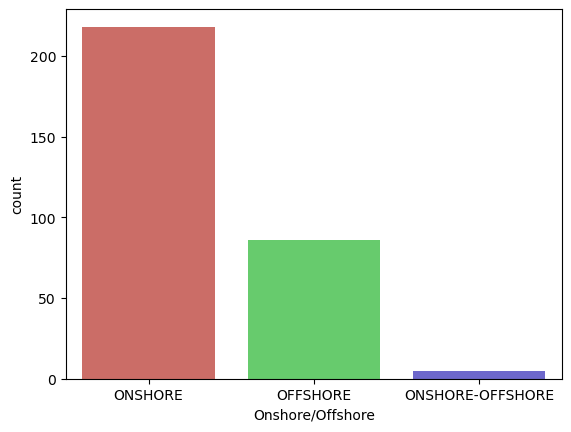

In [106]:
import seaborn as sns
import matplotlib.pyplot as plt

target = 'Onshore/Offshore'

sns.countplot(x=target, data=train, palette='hls', hue=target, legend=False)
plt.show()

In [107]:
from sklearn.preprocessing import LabelEncoder

# Закодируем целевую переменную
# Создание и применение LabelEncoder
encoder = LabelEncoder()
train[target] = encoder.fit_transform(train[target])

# Создание словаря соответствия
label_mapping = {class_name: index for index, class_name in enumerate(encoder.classes_)}

print(label_mapping)

{'OFFSHORE': 0, 'ONSHORE': 1, 'ONSHORE-OFFSHORE': 2}


In [126]:
from sklearn.model_selection import train_test_split

X = train.copy()
y = train[target]

X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.2, 
                                                    random_state=42,
                                                    stratify=y,
                                                   )

print(f'Train shape: {X_train.shape}, {y_train.shape}')
print(f'Test shape: {X_test.shape}, {y_test.shape}')

Train shape: (247, 143), (247,)
Test shape: (62, 143), (62,)


In [127]:
from sklearn.neighbors import KNeighborsClassifier # классификатор
from sklearn.neighbors import KNeighborsRegressor # регрессор

from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score

In [128]:
# Список для хранения всех вариантов модели
# и метрик для каждой из них
scores = []

# переберем соседей от 3 до 16 включительно
for i in range(2, 19):
    # словарь для сохренение метрик для одной модели
    score = {}
    # создаем модель с количеством соседей i
    knn = KNeighborsClassifier(i)
    # обучаем модель
    knn.fit(X_train, y_train)
    # метод predict возвращает вектор ответов для X_test
    answers = knn.predict(X_test) 

    # Оцениваем KNN  с кол-вом сосдей i и сохраняем
    score['k'] = i
    score['accuracy'] = accuracy_score(answers,y_test)
    scores.append(score)

# вывод всех вариантов и их метрик
scores = pd.DataFrame(scores)
scores

,k,accuracy
0,2,0.580645
1,3,0.596774
2,4,0.596774
3,5,0.580645
4,6,0.661290
5,7,0.677419
6,8,0.612903
7,9,0.661290
8,10,0.645161
9,11,0.677419


In [129]:
scores[scores['accuracy'] == scores['accuracy'].max()]

,k,accuracy
14,16,0.725806


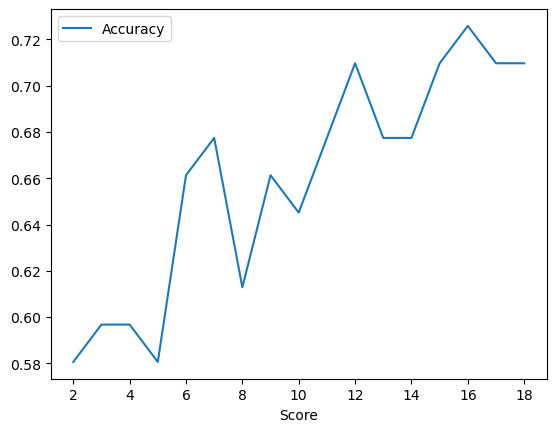

In [130]:
import matplotlib.pyplot as plt

plt.plot(scores['k'], scores['accuracy'], label='Accuracy')
plt.xlabel('K')
plt.xlabel('Score')
plt.legend()

In [132]:
knn = KNeighborsClassifier(16)

# обучаем
knn.fit(X_train,y_train)

# предсказываем значения
y_pred = knn.predict(X_test)

In [133]:
y_pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

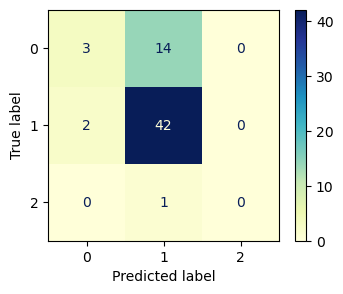

In [134]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix

conf_matrix = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(4,3), dpi=100)

display = ConfusionMatrixDisplay(conf_matrix, display_labels=knn.classes_)

display.plot(ax=ax, cmap='YlGnBu')

In [135]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print()

# 2. Precision (по классам и усредненный)
precision_macro = precision_score(y_test, y_pred, average='macro')
precision_micro = precision_score(y_test, y_pred, average='micro')
precision_weighted = precision_score(y_test, y_pred, average='weighted')

print(f"Precision Macro: {precision_macro:.4f}")
print(f"Precision Micro: {precision_micro:.4f}")
print(f"Precision Weighted: {precision_weighted:.4f}")
print()

# 3. Recall (по классам и усредненный)
recall_macro = recall_score(y_test, y_pred, average='macro')
recall_micro = recall_score(y_test, y_pred, average='micro')
recall_weighted = recall_score(y_test, y_pred, average='weighted')

print(f"Recall Macro: {recall_macro:.4f}")
print(f"Recall Micro: {recall_micro:.4f}")
print(f"Recall Weighted: {recall_weighted:.4f}")
print()

# 4. F1-score (по классам и усредненный)
f1_macro = f1_score(y_test, y_pred, average='macro')
f1_micro = f1_score(y_test, y_pred, average='micro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')

print(f"F1 Macro: {f1_macro:.4f}")
print(f"F1 Micro: {f1_micro:.4f}")
print(f"F1 Weighted: {f1_weighted:.4f}")
print()

# 5. Матрица ошибок (Confusion Matrix)
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)
print()

# 6. Подробный отчет по классам
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7258

Precision Macro: 0.4456
Precision Micro: 0.7258
Precision Weighted: 0.6874

Recall Macro: 0.3770
Recall Micro: 0.7258
Recall Weighted: 0.7258

F1 Macro: 0.3681
F1 Micro: 0.7258
F1 Weighted: 0.6650

Confusion Matrix:
[[ 3 14  0]
 [ 2 42  0]
 [ 0  1  0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.18      0.27        17
           1       0.74      0.95      0.83        44
           2       0.00      0.00      0.00         1

    accuracy                           0.73        62
   macro avg       0.45      0.38      0.37        62
weighted avg       0.69      0.73      0.67        62



/home/itj/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/itj/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/itj/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/itj/

## 7/12   Проверка алгоритма ML с использованием методов балансировки классов (vo_HW)


In [136]:
print(f'Features shape: {X.shape}')
print(f'Classes distribution:\n{y.value_counts()}')

Features shape: (309, 143)
Classes distribution:
Onshore/Offshore
1    218
0     86
2      5
Name: count, dtype: int64


In [137]:
X.columns

Index(['Latitude', 'Longitude', 'Onshore/Offshore', 'Depth', 'Porosity',
       'Has_Gravity', 'Has_Evaporite', 'Has_Compression',
       'log_Thickness (gross average ft)',
       'log_Thickness (net pay average ft)',
       ...
       'Main_Structural_FORELAND', 'Main_Structural_INTRACRATONIC',
       'Main_Structural_INVERSION', 'Main_Structural_PASSIVE MARGIN',
       'Main_Structural_RIFT', 'Main_Structural_SALT',
       'Main_Structural_SUB-SALT', 'Main_Structural_SUB-THRUST',
       'Main_Structural_THRUST', 'Main_Structural_WRENCH'],
      dtype='str', length=143)

In [138]:
from imblearn.over_sampling import SMOTE

# Приводим весь датафрейм к float, чтобы избежать конфликта при интерполяции
X = X.astype('float64')

os = SMOTE(random_state=42, k_neighbors=4)

columns = X.columns

os_data_X, os_data_y = os.fit_resample(X, y)
# fit()
# resample()

os_data_X = pd.DataFrame(os_data_X, columns = columns)
os_data_y = pd.DataFrame(os_data_y, columns = ['class'])

print(f'Features shape after SMOTE: {os_data_X.shape}')
print(f'Classes distribution after SMOTE:\n{os_data_y.value_counts()}')

Features shape after SMOTE: (654, 143)
Classes distribution after SMOTE:
Series([], Name: count, dtype: int64)


In [139]:
X.shape, y.shape

((309, 143), (309,))

In [140]:
os_data_X.shape, os_data_y.shape

((654, 143), (0, 1))

In [141]:
from imblearn.under_sampling import RandomUnderSampler, TomekLinks

# Применяем TomekLinks для очистки границ
tl = TomekLinks()

features_res, labels_res = tl.fit_resample(X_train, y_train)

features_res

,Latitude,Longitude,Onshore/Offshore,Depth,Porosity,Has_Gravity,Has_Evaporite,Has_Compression,log_Thickness (gross average ft),log_Thickness (net pay average ft),...,Main_Structural_FORELAND,Main_Structural_INTRACRATONIC,Main_Structural_INVERSION,Main_Structural_PASSIVE MARGIN,Main_Structural_RIFT,Main_Structural_SALT,Main_Structural_SUB-SALT,Main_Structural_SUB-THRUST,Main_Structural_THRUST,Main_Structural_WRENCH
0,9.6835,-63.4529,1,12750,15.0,0,0,1,7.378384,6.746412,...,0,0,0,0,0,0,0,0,1,0
1,39.4700,52.7300,0,10100,18.0,0,0,1,9.012011,5.564520,...,0,0,0,0,0,0,0,0,1,0
2,52.2830,-113.5543,1,4921,13.2,0,0,1,4.753590,2.397895,...,1,0,0,0,0,0,0,0,0,0
3,65.0789,7.4898,0,6480,27.5,0,0,0,6.131226,5.942799,...,0,0,0,0,1,0,0,0,0,0
4,54.4995,-115.4904,1,8540,9.0,0,0,1,5.442418,4.110874,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
207,37.0386,-101.0039,1,1700,14.0,0,0,1,5.484797,3.828641,...,1,0,0,0,0,0,0,0,0,0
208,56.4125,2.0286,0,7044,13.0,0,0,0,3.433987,3.433987,...,0,0,0,0,1,0,0,0,0,0
209,-5.3099,11.9154,0,3065,24.0,1,0,0,6.111467,5.017280,...,0,0,0,1,0,0,0,0,0,0
210,37.0789,-109.2333,1,5575,14.0,0,0,1,4.394449,3.850148,...,0,1,0,0,0,0,0,0,0,0


In [142]:
labels_res.value_counts()

Onshore/Offshore
1    155
0     53
2      4
Name: count, dtype: int64

In [145]:
# А теперь используем RandomUnderSampler для точной балансировки
K = 4

rus = RandomUnderSampler(sampling_strategy={0: K, 1: K, 2: K}, random_state=42)

balanced_Tomek, labels_resampled = rus.fit_resample(features_res, labels_res)

balanced_Tomek['class'] = labels_resampled

# Проверяем баланс классов
balanced_Tomek['class'].value_counts()

/tmp/ipykernel_342258/4234087458.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  balanced_Tomek['class'] = labels_resampled


class
0    4
1    4
2    4
Name: count, dtype: int64

## RandomOverSampler (случайная генерация объектов)

Этот метод просто дублирует случайные объекты из миноритарных классов до нужного количества. Самый простой способ увеличить данные.

In [146]:
from imblearn.over_sampling import RandomOverSampler

# Создаем экземпляр RandomOverSampler
ros = RandomOverSampler(random_state=42)

# Применяем oversampling к данным
df_rand_over, y_res = ros.fit_resample(X_train, y_train)

df_rand_over['class'] = y_res
# Проверка нового распределения классов
df_rand_over['class'].value_counts()

/tmp/ipykernel_342258/1374472522.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_rand_over['class'] = y_res


class
1    174
0    174
2    174
Name: count, dtype: int64

In [151]:
y_train.value_counts()

Onshore/Offshore
1    174
0     69
2      4
Name: count, dtype: int64

In [152]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
import pandas as pd

# Применение SMOTE к тренировочным данным
smote = SMOTE(random_state=42, k_neighbors=3)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Собираем всё обратно в DataFrame, если нужно
balanced_df_SMOTE = pd.DataFrame(X_train_res, columns=X.columns)
balanced_df_SMOTE['class'] = y_train_res

balanced_df_SMOTE['class'].value_counts()

class
1    174
0    174
2    174
Name: count, dtype: int64

In [155]:
from imblearn.over_sampling import ADASYN

# Создаем экземпляр ADASYN
adasyn = ADASYN(random_state=42, n_neighbors=3)

# Применяем ADASYN
X_ADASYN, y_ADASYN = adasyn.fit_resample(X_train, y_train)

# Собираем всё обратно в DataFrame, если нужно
balanced_df_ADASYN = pd.DataFrame(X_ADASYN, columns=X.columns)
balanced_df_ADASYN['class'] = y_ADASYN

balanced_df_ADASYN['class'].value_counts()

class
0    188
1    174
2    172
Name: count, dtype: int64

In [156]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.model_selection import train_test_split

# Функция для обучения и оценки модели
def train_and_evaluate(X_train, y_train, X_test, y_test, strategy_name):

    # Создаем и обучаем модель KNN
    model = DecisionTreeClassifier()
    model.fit(X_train, y_train)

    # Делаем предсказания на тестовых данных
    y_pred = model.predict(X_test)

    # Выводим результаты
    print(f"Результаты для стратегии: {strategy_name}")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    # {‘micro’, ‘macro’, ‘samples’, ‘weighted’, ‘binary’}
    print(f"f1_score macro: {f1_score(y_test, y_pred, average = 'macro'):.4f}")
    print(f"f1_score_weighted: {f1_score(y_test, y_pred, average = 'weighted'):.4f}")

    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))
    print("="*60)

    res = {'strategy_name': strategy_name,
           'Accuracy': accuracy_score(y_test, y_pred),
           "f1_score_macro": f1_score(y_test, y_pred, average = 'macro'),
           "f1_score_weighted": f1_score(y_test, y_pred, average = 'weighted')}

    return res

# df_rand_undersaml, balanced_Tomek, df_NearMiss
# df_rand_over, balanced_df_SMOTE, balanced_df_ADASYN

# Словарь с датасетами
datasets = {
    'Исходная выбока': (X_train, y_train),
    "Random Undersampling": (df_rand_undersaml.drop(columns=['class']), df_rand_undersaml['class']),
    "Tomek Links + Random Undersampling": (balanced_Tomek.drop(columns=['class']), balanced_Tomek['class']),
    "NearMiss": (df_NearMiss.drop(columns=['class']), df_NearMiss['class']),
    "Random Oversampling": (df_rand_over.drop(columns=['class']), df_rand_over['class']),
    "SMOTE": (balanced_df_SMOTE.drop(columns=['class']), balanced_df_SMOTE['class']),
    "ADASYN": (balanced_df_ADASYN.drop(columns=['class']), balanced_df_ADASYN['class'])
}

# Разбиваем на train/test и оцениваем каждую стратегию
results = []
for strategy, (X_balanced, y_balanced) in datasets.items():
    results.append(train_and_evaluate(X_balanced, y_balanced, X_test, y_test, strategy))

NameError: name 'df_rand_undersaml' is not defined

# Финальный сабмит

In [88]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

In [89]:
display(train.shape)

display(test.shape)

(309, 143)

(133, 142)

In [90]:
train = train.dropna()

display(train.shape)

(309, 143)

In [91]:
# test['Latitude'] = test['Latitude'].fillna(0)
# test['Longitude'] = test['Longitude'].fillna(0)
test = test.fillna(0)

In [92]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Columns: 143 entries, Latitude to Main_Structural_WRENCH
dtypes: float64(6), int64(136), str(1)
memory usage: 347.6 KB


In [93]:
# Получение списка имен категориальных колонок
categorical_cols = train.drop('Onshore/Offshore', axis='columns').select_dtypes(include=['object', 'string']).columns.tolist()

categorical_cols


[]

In [94]:
from sklearn.preprocessing import OrdinalEncoder

# Список категориальных столбцов
categ = categorical_cols

# Создаем OrdinalEncoder, обрабатываем неизвестные категории специальным значением -1
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

train_encoded = encoder.fit_transform(train[categ]) # numpy
test_encoded = encoder.transform(test[categ]) # numpy

# Заменяем старые категориальные столбцы новыми закодированными
train[categ] = train_encoded
test[categ] = test_encoded

In [95]:
display(train.shape)

display(test.shape)

(309, 143)

(133, 142)

In [96]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Создадим модель дерева решений
tree = DecisionTreeClassifier(random_state=42)
knn = KNeighborsClassifier(2)

X = train.drop(columns=['Onshore/Offshore'])
y = train['Onshore/Offshore']
y = le.fit_transform(y)

# обучение модели
tree.fit(X, y)

# предсказание ответов для тестовой выборки
y_pred_tree = tree.predict(test)

y_pred_tree

array([1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 2, 0, 0, 1, 0, 0, 1, 1, 1, 1, 2, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 2, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1])

In [97]:
y_pred_tree.sum()

np.int64(96)

In [98]:
ans_df = pd.DataFrame(y_pred_tree, columns=['Onshore/Offshore'])

ans_df.reset_index(inplace=True)
ans_df.to_csv('./classification-of-oil-and-gas/submition_baseline-fillna_drop-map-group-log_dummies.csv', index=False)

In [99]:
train.describe()

,Latitude,Longitude,Depth,Porosity,Has_Gravity,Has_Evaporite,Has_Compression,log_Thickness (gross average ft),log_Thickness (net pay average ft),log_Permeability,...,Main_Structural_FORELAND,Main_Structural_INTRACRATONIC,Main_Structural_INVERSION,Main_Structural_PASSIVE MARGIN,Main_Structural_RIFT,Main_Structural_SALT,Main_Structural_SUB-SALT,Main_Structural_SUB-THRUST,Main_Structural_THRUST,Main_Structural_WRENCH
count,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,...,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000
mean,35.831253,-13.307824,6755.669903,17.825178,0.181230,0.012945,0.663430,5.825859,4.598585,4.230052,...,0.268608,0.106796,0.067961,0.042071,0.174757,0.106796,0.042071,0.019417,0.080906,0.035599
std,21.655467,85.470516,3628.094135,7.171048,0.385833,0.113221,0.473303,1.219818,1.134153,2.249044,...,0.443955,0.309355,0.252087,0.201077,0.380375,0.309355,0.201077,0.138211,0.273133,0.185588
min,-38.398900,-151.615300,220.000000,1.100000,0.000000,0.000000,0.000000,2.484907,1.137833,0.009950,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28.533300,-102.230000,4059.000000,12.000000,0.000000,0.000000,0.000000,4.859812,3.828641,2.397895,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,38.621600,1.810000,6500.000000,17.000000,0.000000,0.000000,1.000000,5.746203,4.709530,4.234107,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,51.400100,54.926900,9186.000000,23.600000,0.000000,0.000000,1.000000,6.573680,5.327876,5.968708,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,76.446200,148.417000,19888.000000,35.000000,1.000000,1.000000,1.000000,9.012011,7.998671,8.922792,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [100]:
train['Onshore/Offshore'].value_counts()

Onshore/Offshore
ONSHORE             218
OFFSHORE             86
ONSHORE-OFFSHORE      5
Name: count, dtype: int64

In [101]:
pd.__version__

'3.0.2'